#HW 5 - CNN Sketch Classification (10 pts)

For homework assignment HW 5, you will implement a sketch classifier using the Google QuickDraw dataset:
1. Select at least 5 classes for training and testing.

2. Baseline Implementation: implement the classifier using Lab 2 architecture to establish a performance baseline. (1/10 pts)

3. Re-implement the classifier using CNN and conduct experiments to compare the performance of the classic NN against the CNN. (5/10 pts)

4. Experiment Report (max 6 pages): You are required to conduct a comparative performance analysis of your models with at least 100 test sketches (from the dataset) for each class. You **MUST** experiment with different model configurations for your CNN (e.g. different hidden layer size, more or less convolution layers, batch norm, dropout, etc.) to make it better. Document your findings with comparative screenshots of classification outputs and specify the configuration that gives you the best results. Report the accuracy rate for different model configurations. (4/10 pts)


Note:
1. You can use smaller training data size (so faster training) as long as you get reasonable classification results.
2. You can split the dataset, use a subset as training set and use another 100 or more sketches as the test set.

In [13]:
# Hyperparameters

batch_size = 64
stride = 1
padding = 1
kernel_size = 3
learning_rate = 0.003
epochs = 5

In [14]:
import os
import urllib.request

# Define categories to download
# See all the categories at:
# https://github.com/googlecreativelab/quickdraw-dataset/blob/master/categories.txt

# categories = ['class 1', 'class 2', 'class 3', 'class 4', 'class 5',
#               'class 6', 'class 7', 'class 8', 'class 9', 'class 10']

categories = [
    'baseball bat',
    'bridge',
    'calendar',
    'hedgehog',
    'helmet',
    'octopus',
    'pineapple',
    'rainbow',
    'toaster',
    'windmill'
]

base_url = "https://storage.googleapis.com/quickdraw_dataset/full/numpy_bitmap/"

if not os.path.exists('data'):
    os.mkdir('data')

for cat in categories:
    url = f"{base_url}{cat.replace(' ', '%20')}.npy"    # replace spaces with %20
    path = f"data/{cat}.npy"
    if not os.path.exists(path):
        print(f"Downloading {cat}...")
        urllib.request.urlretrieve(url, path)


        

In [15]:
import numpy as np
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader, random_split
from torchvision import transforms

class QuickDrawDataset(Dataset):
    def __init__(self, root, categories, max_items=10000, transform=None):
        super().__init__()
        self.data, self.labels = [], []
        self.transform = transform

        for idx, cat in enumerate(categories):
            # Load as raw uint8 (0-255)
            data = np.load(f"{root}/{cat}.npy")[:max_items]
            self.data.append(data)
            self.labels.extend([idx] * len(data))

        self.data = np.concatenate(self.data).astype(np.uint8)
        self.labels = np.array(self.labels)

    def __len__(self):
        return len(self.data)

    def __getitem__(self, idx):
        image = self.data[idx].reshape(28, 28)
        label = self.labels[idx]

        # Apply transforms
        if self.transform:
            image = self.transform(image)
        return image, label

# Setup
raw_dataset = QuickDrawDataset(root='./data', categories=categories, max_items=100)

loader = DataLoader(raw_dataset, batch_size=batch_size)

# Get mean and std from all images
all_images, all_labels = next(iter(loader))
all_images = all_images.float()

# Global mean and std
mean, std = all_images.mean().item(), all_images.std().item()
print(f"{mean=:.2f}, {std=:.2f}")
# Normalize the intensity (mean) and contrast (std)
raw_dataset.transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((mean/255.0,), (std/255.0,))
])


train_size = int(0.5 * len(raw_dataset))
test_size = len(raw_dataset) - train_size
train_dataset, test_dataset = random_split(raw_dataset, [train_size, test_size])

train_loader = DataLoader(
    train_dataset, 
    batch_size=batch_size, 
    shuffle=True,
)

test_loader = DataLoader(
    test_dataset, 
    batch_size=batch_size, 
    shuffle=False,
)

mean=29.47, std=71.32


In [16]:
# Classic neural network
class Net(nn.Module):
    def __init__(self):
        super(Net, self).__init__()
        # Flatten the raw image from 28x28 to 784x1
        self.flatten = nn.Flatten()
        # Construct the layers of the network
        # nn.Sequential is the container for stacking layers
        self.layers = nn.Sequential(
            # Input layer (784 neurons) -> hidden layer (128 neurons)
            nn.Linear(784, 128),
            # Activation
            nn.ReLU(),
            # Dropout
            nn.Dropout(0.2),
            # Hidden layer (128 neurons) -> output layer (10 neurons)
            nn.Linear(128, 10),

            # Comment out if using criterion = nn.CrossEntropyLoss()
            # nn.LogSoftmax(dim=1)
        )

    def forward(self, x):
        x = self.flatten(x)
        logits = self.layers(x)
        return logits



Start training...
Epoch 1 complete. Test acc 61.800
Epoch 2 complete. Test acc 65.000
Epoch 3 complete. Test acc 63.000
Epoch 4 complete. Test acc 64.200
Epoch 5 complete. Test acc 65.600


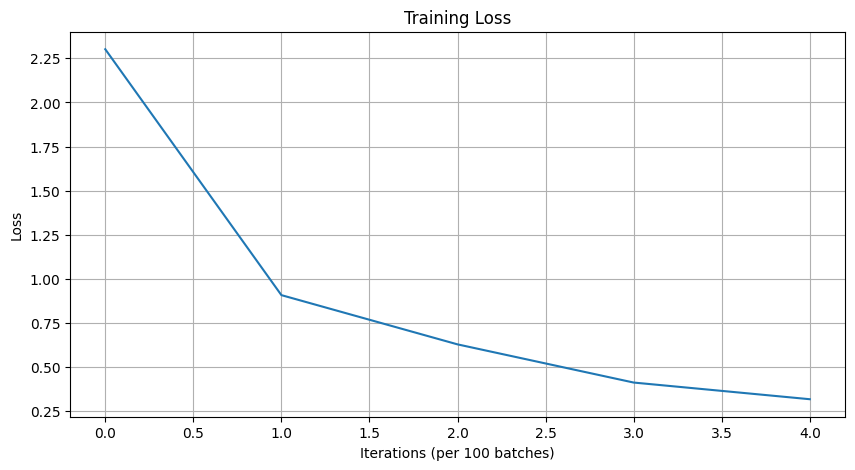

In [17]:

def test(model, test_loader):
    model.eval()
    correct = 0
    total = 0
    with torch.no_grad():
        for data, target in test_loader:
            output = model(data)
            pred = output.argmax(dim=1)
            correct += (pred == target).sum().item()
            total += target.size(0)
    accuracy = 100.0 * correct / total
    return accuracy


model = Net()
optimizer = optim.Adam(model.parameters(), lr=0.003)
# Comment out if using criterion = nn.CrossEntropyLoss()
# criterion = nn.NLLLoss()

# Comment out if using nn.LogSoftmax(dim=1) and criterion = nn.NLLLoss()
criterion = nn.CrossEntropyLoss()

# Training
epochs = 5
losses = []
acc = []

print("Start training...")
for epoch in range(epochs):
    model.train()
    
    for batch_idx, (data, target) in enumerate(train_loader):
        # Reset gradients
        optimizer.zero_grad()
        # Forward pass
        output = model(data)
        # Loss function
        loss = criterion(output, target)
        # Backpropagation
        loss.backward()
        # Update parameters
        optimizer.step()

        if batch_idx % 100 == 0:
            losses.append(loss.item())

    # Test once per epoch
    acc.append(test(model, test_loader))
    print(f"Epoch {epoch+1} complete. Test acc {acc[-1]:.3f}")

# Plot Loss
plt.figure(figsize=(10, 5))
plt.plot(losses)
plt.title("Training Loss")
plt.xlabel("Iterations (per 100 batches)")
plt.ylabel("Loss")
plt.grid(True)
plt.show()

Drawing Canvas for Testing

In [ ]:
from IPython.display import HTML, display
from google.colab import output

canvas_html = """
<canvas id="main_canvas" width="100" height="100" style="border:1px solid #000;"></canvas>
<button id="finish_btn">Predict</button>
<script>
window.getCanvasData = function() {
  return new Promise(resolve => {
    document.getElementById('finish_btn').onclick = () => {
      resolve(document.getElementById('main_canvas').toDataURL('image/png'));
    };
  });
}
</script>
"""

display(HTML(canvas_html))
print("Draw and click Predict...")
data_url = output.eval_js("getCanvasData()")
print("Got data:", data_url[:30], "...")

Draw and click Predict...


In [23]:
import numpy as np
from IPython.display import HTML, display
from google.colab import output
import cv2
import torch
import base64
import matplotlib.pyplot as plt

canvas_html = """
<div style="border: 1px solid #ccc; padding: 20px; width: 320px; text-align: center; background-color: #f9f9f9; border-radius: 10px;">
    <canvas id="main_canvas" width="280" height="280" style="border:2px solid #000; cursor: crosshair; background-color: black;"></canvas>
    <br><br>
    <button id="clear_btn" style="padding: 10px 20px; cursor: pointer;">Clear</button>
    <button id="finish_btn" style="padding: 10px 20px; cursor: pointer; background-color: #4CAF50; color: white; border: none; border-radius: 5px;">Predict</button>
</div>

<script>
    var canvas = document.getElementById('main_canvas');
    var ctx = canvas.getContext('2d');
    var finish_btn = document.getElementById('finish_btn');
    var clear_btn = document.getElementById('clear_btn');
    var drawing = false;

    ctx.strokeStyle = "white";
    ctx.lineWidth = 10;
    ctx.lineCap = "round";
    ctx.lineJoin = "round";

    canvas.addEventListener('mousedown', (e) => { drawing = true; ctx.beginPath(); ctx.moveTo(e.offsetX, e.offsetY); });
    canvas.addEventListener('mousemove', (e) => { if(drawing) { ctx.lineTo(e.offsetX, e.offsetY); ctx.stroke(); } });
    canvas.addEventListener('mouseup', () => { drawing = false; });

    clear_btn.onclick = () => { ctx.clearRect(0, 0, canvas.width, canvas.height); };

    // This function returns a promise that Colab's eval_js will wait for
    var getCanvasData = new Promise(resolve => {
        finish_btn.onclick = () => {
            resolve(canvas.toDataURL('image/png'));
        };
    });
</script>
"""

def get_prediction():
    display(HTML(canvas_html))

    data_url = output.eval_js("getCanvasData")
    print("Clicked Predict!")

    try:
        header, encoded = data_url.split(",", 1)
        binary = base64.b64decode(encoded)
        nparr = np.frombuffer(binary, np.uint8)

        # Read as BGR then convert to Gray to handle transparency/alpha correctly
        img = cv2.imdecode(nparr, cv2.IMREAD_UNCHANGED)
        if img.shape[-1] == 4:  # If there's an alpha channel
            # Create a black background and paste the drawing onto it
            background = np.zeros((280, 280), dtype=np.uint8)
            alpha_channel = img[:, :, 3]
            img_gray = alpha_channel # In our canvas, alpha represents the white strokes
        else:
            img_gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

        # Resize and Normalize
        img_28 = cv2.resize(img_gray, (28, 28), interpolation=cv2.INTER_AREA)

        # Match the QuickDraw format (0 to 1 range)
        img_tensor = torch.from_numpy(img_28).float() / 255.0
        # normalization
        img_tensor = (img_tensor - 0.5) / 0.5
        img_tensor = img_tensor.unsqueeze(0).unsqueeze(0).to(device)

        # Prediction
        model.eval()
        with torch.no_grad():
            output_logits = model(img_tensor)
            if isinstance(criterion, nn.NLLLoss):
                output_logits = torch.softmax(output_logits, dim=1)
            prob, pred_idx = torch.max(output_logits, 1)

        # Visual Result
        # Mapping index back to class name
        label = categories[pred_idx.item()] if 'categories' in globals() else pred_idx.item()

        plt.figure(figsize=(3, 3))
        plt.imshow(img_28, cmap='gray')
        plt.title(f"Result: {label}\nConf: {prob.item()*100:.1f}%")
        plt.axis('off')
        plt.show()

    except Exception as e:
        print(f"Error: {e}")

# Run the test
get_prediction()

KeyboardInterrupt: 